In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from concept_abstraction.plotting import *
from concept_abstraction.utils import *

In [3]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [33]:
style_size = 'paper'

## Synthetic Environments

### Time

In [60]:
environment_nodes = [4,8,16]
baseline_params = {'environment_string': 'cycle', 'show_baseline': True, 'num_concepts_selected': 4}
time_taken_by_node = []
confidences_by_node = []

for n in environment_nodes:
    baseline_params['environment_nodes'] = n
    results = get_results_matching_parameters("synthetic","",baseline_params)
    all_time_taken = []
    for r in results:
        all_time_taken.append(r['random_selection']['time'])
    all_time_taken = np.array(all_time_taken)
    time_taken_by_node.append(np.mean(all_time_taken,axis=0))
    confidences_by_node.append(np.std(all_time_taken,axis=0)/len(all_time_taken)**.5)


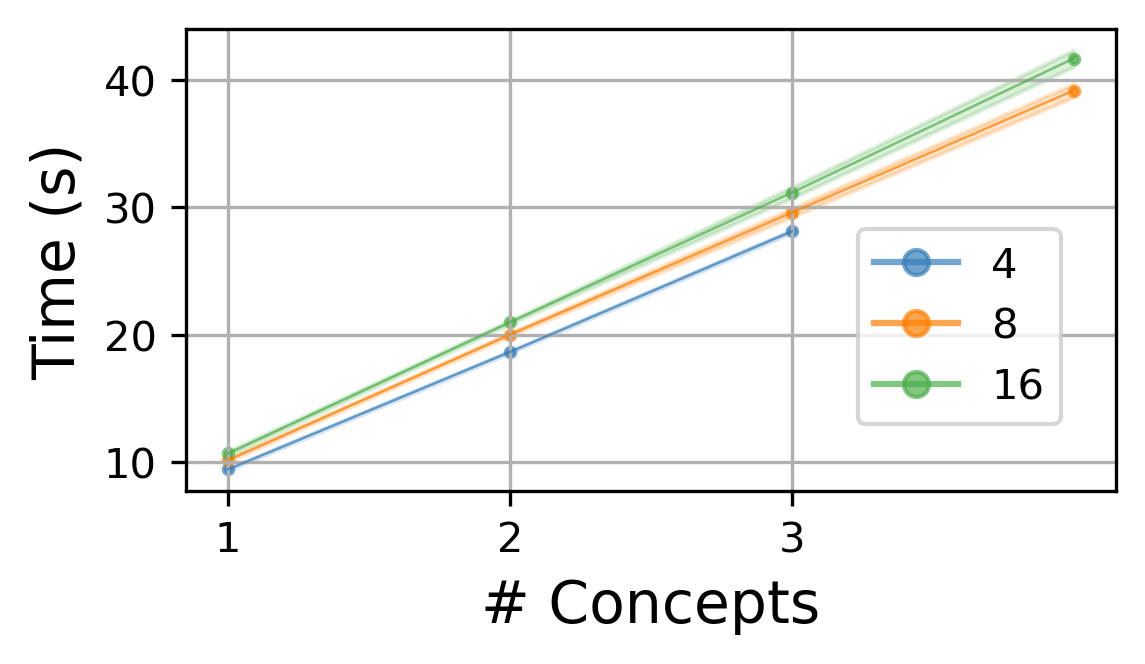

In [61]:
plot_dimensions = (1,1)
x_labels = [["# Concepts"]]
y_labels = [["Time (s)"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[[0,1,2],[1,2,3]]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(time_taken_by_node[i]))) for i in range(len(time_taken_by_node))],time_taken_by_node,confidences_by_node,environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(time_taken_by_node[i]))) for i in range(len(time_taken_by_node))],time_taken_by_node,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/time_taken_cycle.pdf",dpi=300, bbox_inches='tight')

In [62]:
environment_nodes = [3,7,15,31,63,127]
baseline_params = {'environment_string': 'tree', 'show_baseline': True, 'num_concepts_selected': 4}
time_taken_by_node = []
confidences_by_node = []

for n in environment_nodes:
    baseline_params['environment_nodes'] = n
    results = get_results_matching_parameters("synthetic","",baseline_params)
    all_time_taken = []
    for r in results:
        all_time_taken.append(r['random_selection']['time'])
    all_time_taken = np.array(all_time_taken)
    time_taken_by_node.append(np.mean(all_time_taken,axis=0))
    confidences_by_node.append(np.std(all_time_taken,axis=0)/len(all_time_taken)**.5)


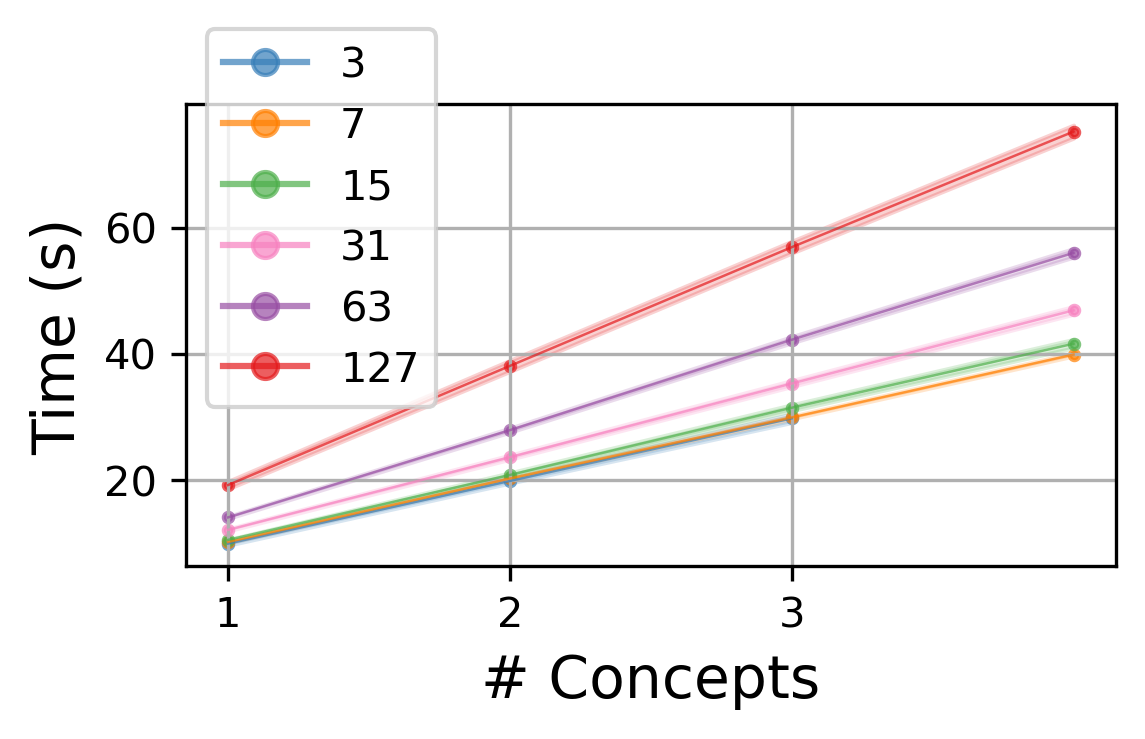

In [67]:
plot_dimensions = (1,1)
x_labels = [["# Concepts"]]
y_labels = [["Time (s)"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[[0,1,2],[1,2,3]]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(time_taken_by_node[i]))) for i in range(len(time_taken_by_node))],time_taken_by_node,confidences_by_node,environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(time_taken_by_node[i]))) for i in range(len(time_taken_by_node))],time_taken_by_node,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0,0.3), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/time_taken_tree.pdf",dpi=300, bbox_inches='tight')

### Concept Selection

In [106]:
environment_nodes = [4,8,16]
baseline_params = {'environment_string': 'cycle', 'show_baseline': True, 'num_concepts_selected': 4}
value_difference = {
    'greedy': [], 'random': [],
}
confidences_by_node = {
    'greedy': [], 'random': [],
}

for method in ['random','greedy']:
    for n in environment_nodes:
        baseline_params['environment_nodes'] = n
        results = get_results_matching_parameters("synthetic","",baseline_params)
        value_difference_local = []
        for r in results:
            baseline = np.array(r['baseline']['values'][0])

            for val in r['{}_selection'.format(method)]['values']: 
                value_difference_local.append(np.max(np.abs(np.array(val)-baseline)))
        value_difference_local = np.array(value_difference_local)
        value_difference[method].append(np.mean(value_difference_local,axis=0))
        confidences_by_node[method].append(np.std(value_difference_local,axis=0)/len(value_difference)**.5)


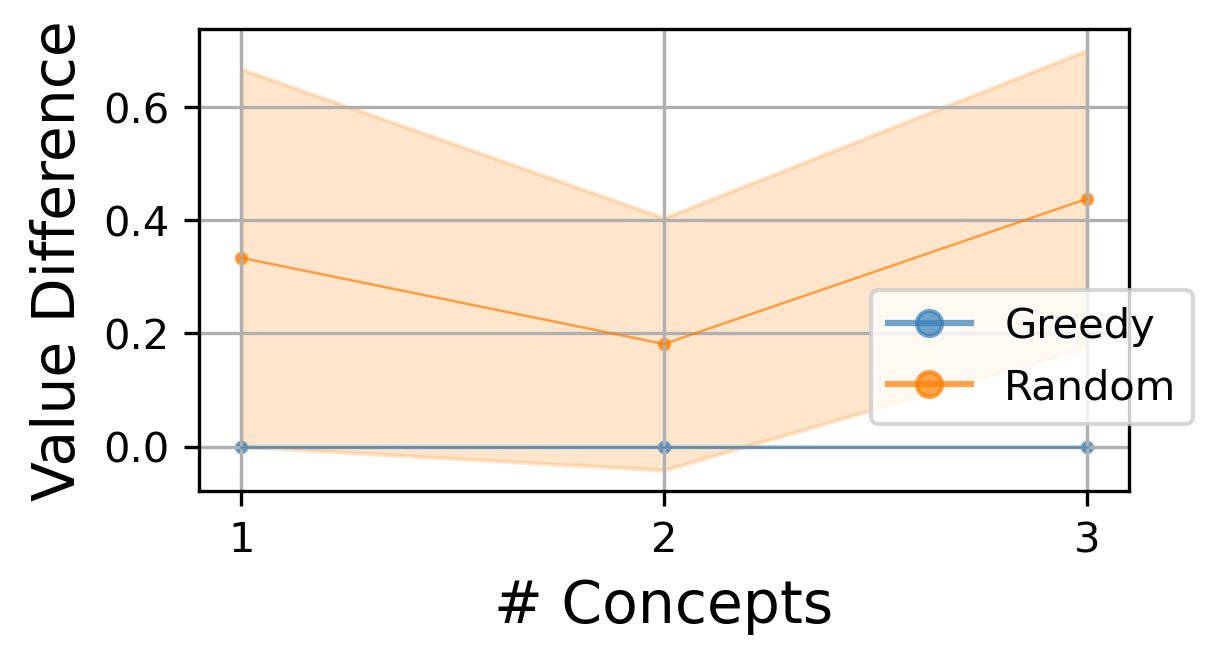

In [107]:
plot_dimensions = (1,1)
x_labels = [["# Concepts"]]
y_labels = [["Value Difference"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[[0,1,2],[1,2,3]]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(value_difference[method]))) for method in ['greedy','random']],[value_difference[method] for method in ['greedy','random']],[confidences_by_node[method] for method in ['greedy','random']],['Greedy','Random'],line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(value_difference[method]))) for method in ['greedy','random']],[value_difference[method] for method in ['greedy','random']],line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/value_differences_cycle.pdf",dpi=300, bbox_inches='tight')

In [127]:
environment_nodes = [3,7,15,31,63,127]
baseline_params = {'environment_string': 'tree', 'show_baseline': True, 'num_concepts_selected': 4}
value_difference  = {
    'greedy': [], 'random': [],
}

confidences_by_node = {
    'greedy': [], 'random': [],
}

for method in ['random','greedy']:
    for n in environment_nodes:
        baseline_params['environment_nodes'] = n
        results = get_results_matching_parameters("synthetic","",baseline_params)
        print(len(results))
        value_difference_local = []
        for r in results:
            baseline = np.array(r['baseline']['values'][0])
            temp = []
            for num_selections in range(len(r['{}_selection'.format(method)]['values'])):
                temp.append(np.max(np.abs(np.array(r['{}_selection'.format(method)]['values'][num_selections])-baseline)))
            value_difference_local.append(temp)
        value_difference_local = np.array(value_difference_local)
        value_difference[method].append(np.mean(value_difference_local,axis=0))
        confidences_by_node[method].append(np.std(value_difference_local,axis=0)/len(value_difference_local)**.5)


3
3
3
3
3
3
3
3
3
3
3
3


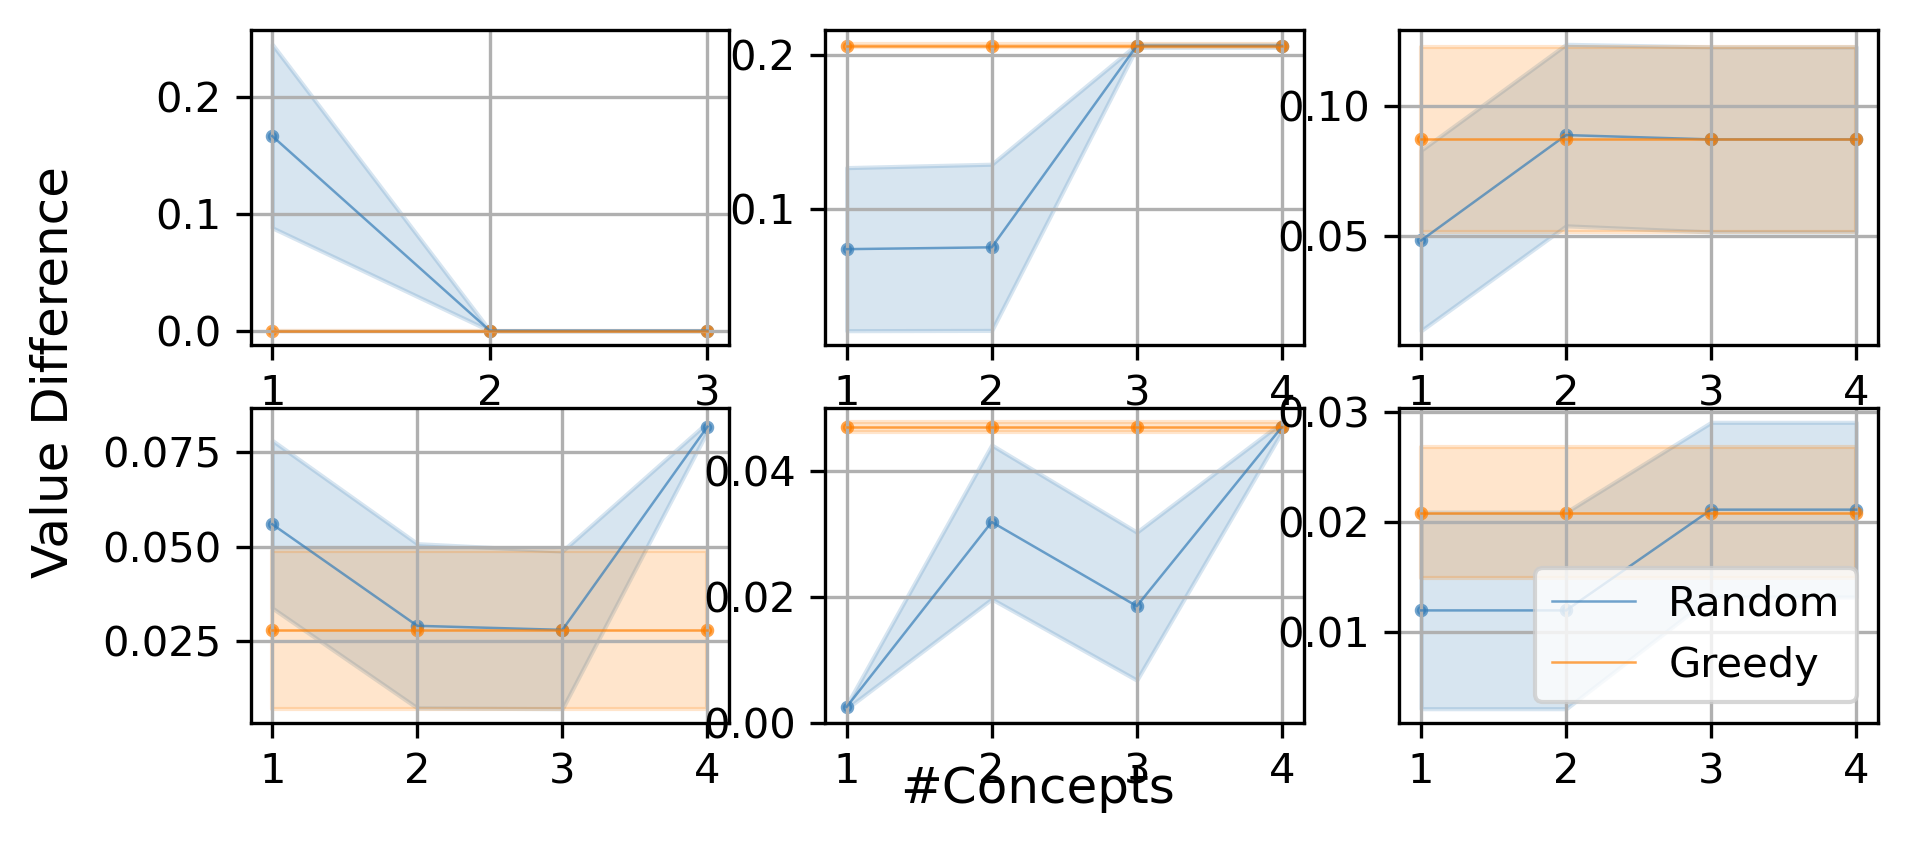

In [128]:
plot_dimensions = (2,3)
x_labels = [["","",""],["","",""]]
y_labels = [["","",""],["","",""]]
sup_y_label = "Value Difference"
sup_x_label = "#Concepts"
overall_format = {'figsize':(7,3),
    'style_size': style_size,
    'x_ticks': [[[[0,1,2,3],[1,2,3,4]] for i in range(3)] for j in range(2)],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label,sup_x_label=sup_x_label)
line_format = {'color_palette': 'six_color', 'linewidth': 10}
scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

for i in range(2):
    for j in range(3):
        
        plot_line(ax[i][j],[list(range(len(value_difference[method][i*3+j]))) for method in ['random','greedy']],[value_difference[method][i*3+j] for method in ['random','greedy']],[confidences_by_node[method][i*3+j] for method in ['random','greedy']],['Random','Greedy'],line_format)
        plot_scatter(ax[i][j],[list(range(len(value_difference[method][i*3+j]))) for method in ['random','greedy']],[value_difference[method][i*3+j] for method in ['random','greedy']],line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
plt.legend()
fig.savefig("../../results/figures/value_differences_tree.pdf",dpi=300, bbox_inches='tight')

### Concept Error

In [150]:
environment_nodes = [4,8,16]
fixed_accuracy = [0.1,0.25,0.5,0.75,0.9,0.99]

performance_gap = []

for n in environment_nodes:
    baseline_params = {'environment_string': 'cycle', 'environment_nodes': n,'show_baseline': True, 'num_concepts_selected': 4}
    results = get_results_matching_parameters("synthetic","",baseline_params)
    baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
    
    baseline_params['show_baseline'] = False 

    all_values = []

    for acc in fixed_accuracy:
        baseline_params['cbm_accuracy_by_concept'] = [acc for i in range(n-1)]
        baseline_params['num_concepts_selected'] = 0
        results = get_results_matching_parameters("synthetic","",baseline_params)
        
        predicted_values = np.mean([r['uncertainty']['values'][1] for r in results],axis=0)
        diff = np.max(np.abs(predicted_values-baseline_values))
        all_values.append(diff)
    performance_gap.append(all_values)

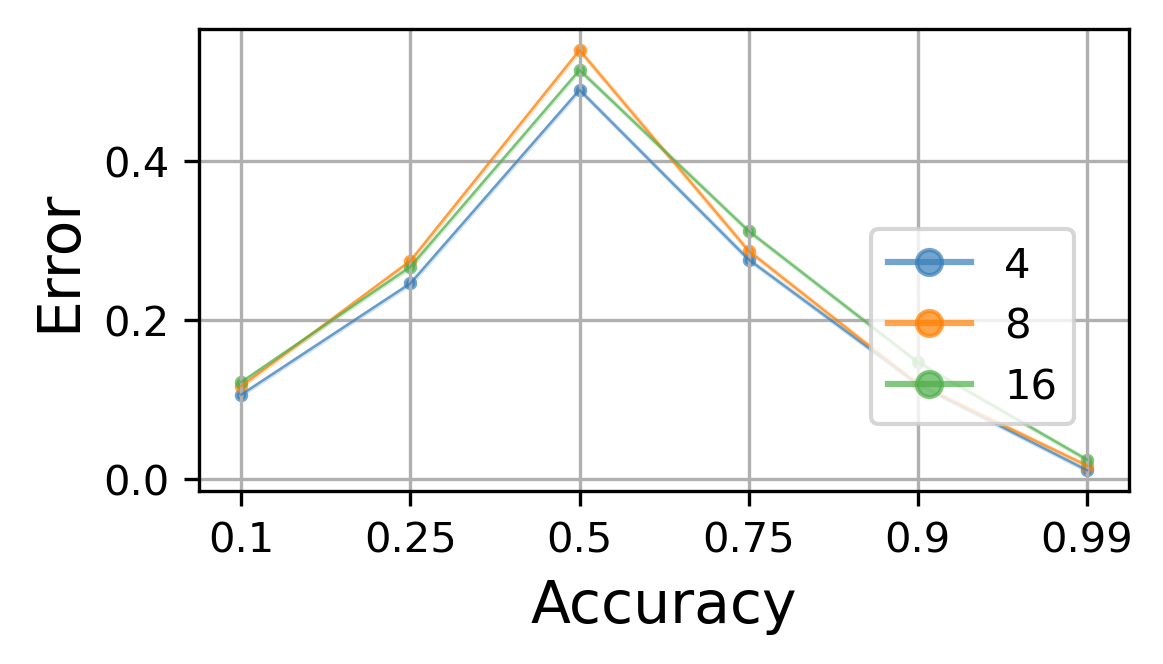

In [154]:
plot_dimensions = (1,1)
x_labels = [["Accuracy"]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(fixed_accuracy))),fixed_accuracy]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,[[0 for i in range(len(performance_gap[i]))] for i in range(len(performance_gap))],environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/uncertainty_cycle.pdf",dpi=300, bbox_inches='tight')

In [158]:
environment_nodes = [15,127]
fixed_accuracy = [0.1,0.25,0.5,0.75,0.9,0.99]

performance_gap = []

for n in environment_nodes:
    baseline_params = {'environment_string': 'tree', 'environment_nodes': n,'show_baseline': True, 'num_concepts_selected': 4}
    results = get_results_matching_parameters("synthetic","",baseline_params)
    baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
    
    baseline_params['show_baseline'] = False 

    all_values = []

    for acc in fixed_accuracy:
        baseline_params['cbm_accuracy_by_concept'] = [acc for i in range(int(np.log2(n+1))+1)]
        baseline_params['num_concepts_selected'] = 0
        results = get_results_matching_parameters("synthetic","",baseline_params)
        
        predicted_values = np.mean([r['uncertainty']['values'][1] for r in results],axis=0)
        diff = np.max(np.abs(predicted_values-baseline_values))
        all_values.append(diff)
    performance_gap.append(all_values)

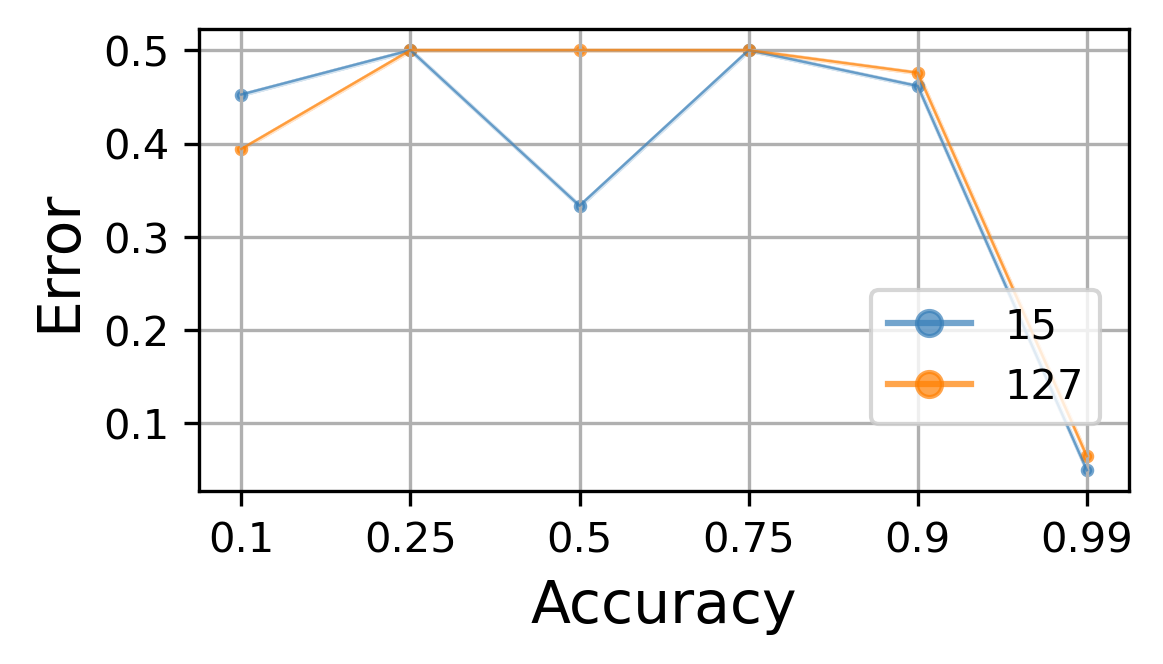

In [160]:
plot_dimensions = (1,1)
x_labels = [["Accuracy"]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(fixed_accuracy))),fixed_accuracy]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,[[0 for i in range(len(performance_gap[i]))] for i in range(len(performance_gap))],environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/uncertainty_tree.pdf",dpi=300, bbox_inches='tight')

In [172]:
human_accuracy_by_concept = [0.9,0.9,0.9]
human_reliance_by_concept = [0.75,0.75,0.75]
baseline_params = {'environment_string': 'cycle', 'environment_nodes': 4,'show_baseline': True, 'num_concepts_selected': 4}
results = get_results_matching_parameters("synthetic","",baseline_params)
baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
baseline_params['show_baseline'] = False 

use_offline_concepts = []
select_new_concepts = []
for cbm_accuracy in [[0.5,1,1],[1,0.5,1],[1,1,0.5]]:
    baseline_params['cbm_accuracy_by_concept'] = cbm_accuracy
    baseline_params['num_concepts_selected'] = 0
    baseline_params['human_reliance_by_concept'] = [0.75,0.75,0.75]
    results = get_results_matching_parameters("synthetic","",baseline_params)
    
    predicted_values = np.mean([r['uncertainty']['values'][1] for r in results],axis=0)
    diff = np.max(np.abs(predicted_values-baseline_values))
    use_offline_concepts.append(diff)

    predicted_values = np.mean([r['uncertainty']['combined_value'] for r in results],axis=0)
    diff = np.max(np.abs(predicted_values-baseline_values))
    select_new_concepts.append(diff)

2 six_color 3


(<Figure size 1200x600 with 1 Axes>, [[<AxesSubplot: ylabel='Error'>]])

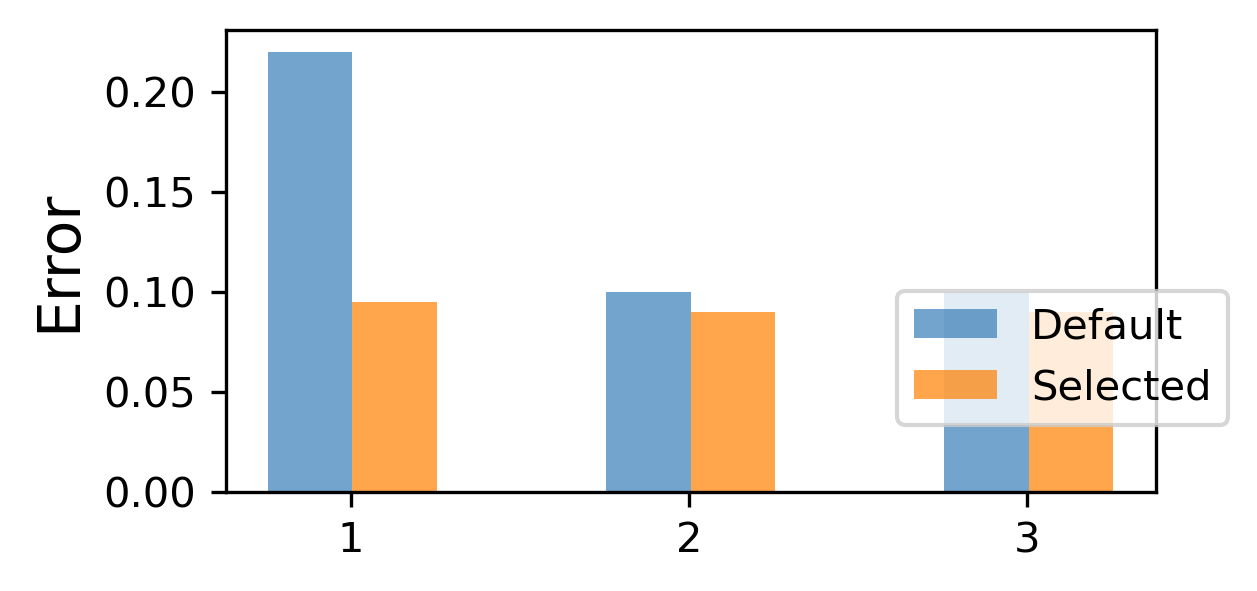

In [206]:
plot_dimensions = (1,1)
x_labels = [[""]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[[0.12,1.12,2.12],[1,2,3]]]],
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size}
y_values = np.array([use_offline_concepts,select_new_concepts]).T.flatten()
plot_bar(ax[0][0],[1,2,1,2,1,2],y_values,[0 for i in range(len(y_values))], {1: 'Default',2: 'Selected'},bar_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)


In [223]:
human_accuracy_by_concept = [0.9,0.9,0.9,0.9,0.9]
human_reliance_by_concept = [0.75,0.75,0.75,0.75,0.75]
baseline_params = {'environment_string': 'tree', 'environment_nodes': 15,'show_baseline': True, 'num_concepts_selected': 4}
results = get_results_matching_parameters("synthetic","",baseline_params)
baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
baseline_params['show_baseline'] = False 

use_offline_concepts = []
less_human_reliance = []
select_new_concepts = []
for cbm_accuracy in [[0.5,1,1,1,1],[1,0.5,1,1,1],[1,1,0.5,1,1],[1,1,1,0.5,1],[1,1,1,1,0.5]]:
    baseline_params['cbm_accuracy_by_concept'] = cbm_accuracy
    baseline_params['num_concepts_selected'] = 0
    baseline_params['human_reliance_by_concept'] = [0.75,0.75,0.75,0.75,0.75]
    results = get_results_matching_parameters("synthetic","",baseline_params)
    print(len(results))
    predicted_values = np.mean([r['uncertainty']['values'][1] for r in results],axis=0)
    diff = np.max(np.abs(predicted_values-baseline_values))
    use_offline_concepts.append(diff)

    predicted_values = np.mean([r['uncertainty']['combined_value'] for r in results],axis=0)
    diff = np.max(np.abs(predicted_values-baseline_values))
    select_new_concepts.append(diff)

for cbm_accuracy in [[0.25,1,1,1,1],[1,0.25,1,1,1],[1,1,0.25,1,1],[1,1,1,0.25,1],[1,1,1,1,0.25]]:
    baseline_params['cbm_accuracy_by_concept'] = cbm_accuracy
    baseline_params['human_reliance_by_concept'] = [0.1,0.1,0.1,0.1,0.1]
    results = get_results_matching_parameters("synthetic","",baseline_params)
    predicted_values = np.mean([r['uncertainty']['values'][1] for r in results],axis=0)
    diff = np.max(np.abs(predicted_values-baseline_values))
    less_human_reliance.append(diff)


3
3
3
0
3


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


3 six_color 5


(<Figure size 1200x600 with 1 Axes>, [[<AxesSubplot: ylabel='Error'>]])

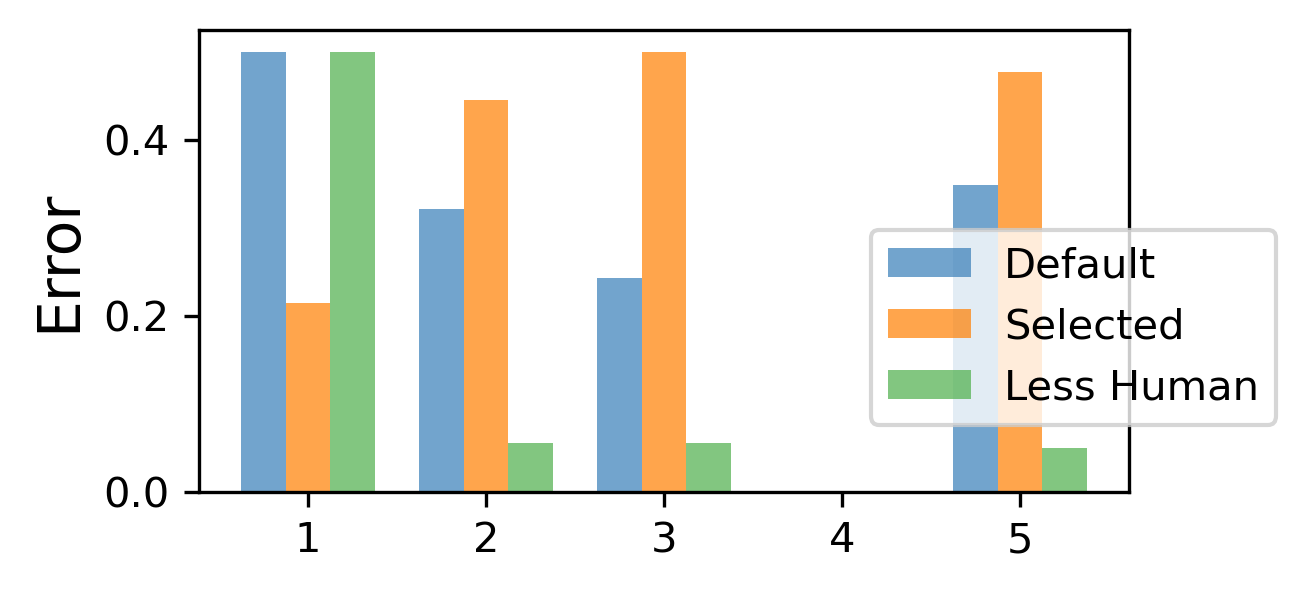

In [221]:
plot_dimensions = (1,1)
x_labels = [[""]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[[0.25,1.25,2.25,3.25,4.25],[1,2,3,4,5]]]],
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size}
y_values = np.array([use_offline_concepts,select_new_concepts,less_human_reliance]).T.flatten()
plot_bar(ax[0][0],[1,2,3,1,2,3,1,2,3,1,2,3,1,2,3],y_values,[0 for i in range(len(y_values))], {1: 'Default',2: 'Selected',3:'Less Human'},bar_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)


In [246]:
environment_nodes = [4]
reward_error = [0.1,0.25,0.5,0.75,1,1.25,1.5,1.75,2]

performance_gap = []

for n in environment_nodes:
    baseline_params = {'environment_string': 'cycle', 'environment_nodes': n,'show_baseline': True, 'num_concepts_selected': 4}
    results = get_results_matching_parameters("synthetic","",baseline_params)
    baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
    
    baseline_params['show_baseline'] = True 

    all_values = []

    for error in reward_error:
        baseline_params['reward_error'] = error 
        baseline_params['num_concepts_selected'] = 3
        results = get_results_matching_parameters("synthetic","",baseline_params)
        
        predicted_values = np.mean([r['greedy_selection']['values'][0] for r in results],axis=0)
        diff = np.max(np.abs(predicted_values-baseline_values))
        all_values.append(diff)
    performance_gap.append(all_values)

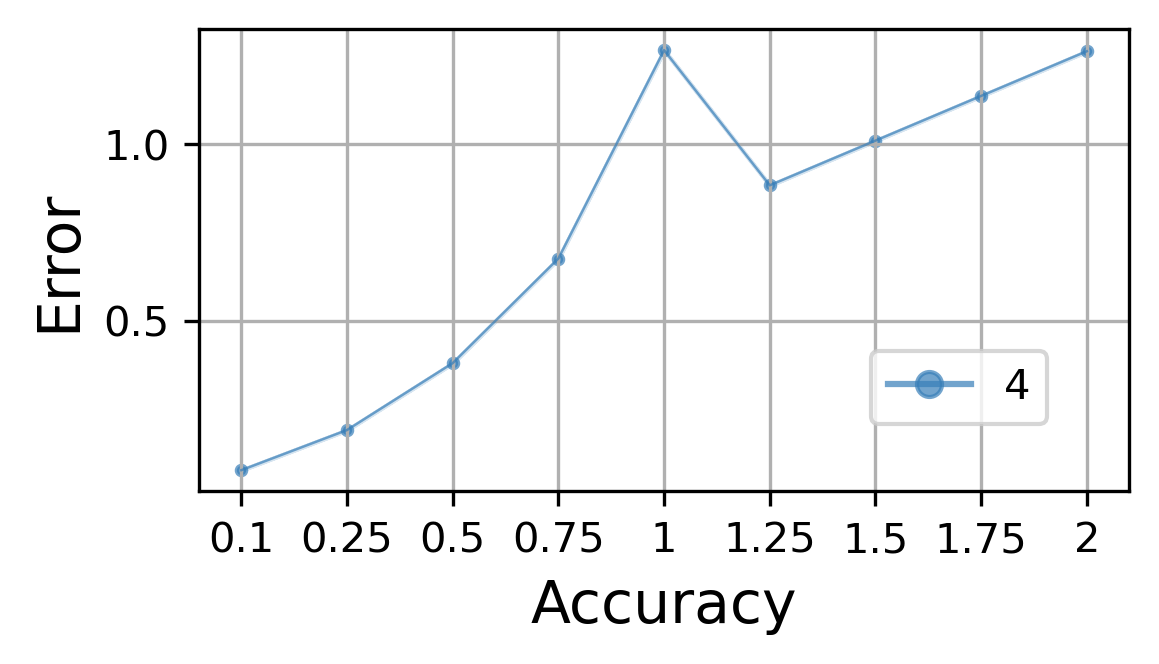

In [247]:
plot_dimensions = (1,1)
x_labels = [["Accuracy"]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(reward_error))),reward_error]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,[[0 for i in range(len(performance_gap[i]))] for i in range(len(performance_gap))],environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/uncertainty_tree.pdf",dpi=300, bbox_inches='tight')

In [252]:
environment_nodes = [4]
reward_error = [0.1,0.25,0.5,0.75,1,1.25,1.5,1.75,2]

performance_gap = []

for n in environment_nodes:
    baseline_params = {'environment_string': 'cycle', 'environment_nodes': n,'show_baseline': True, 'num_concepts_selected': 4}
    results = get_results_matching_parameters("synthetic","",baseline_params)
    baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
    
    baseline_params['show_baseline'] = False 

    all_values = []

    for error in reward_error:
        baseline_params['transition_error'] = error 
        baseline_params['num_concepts_selected'] = 3
        results = get_results_matching_parameters("synthetic","",baseline_params)
        
        predicted_values = np.mean([r['greedy_selection']['values'][0] for r in results],axis=0)
        diff = np.max(np.abs(predicted_values-baseline_values))
        all_values.append(diff)
    performance_gap.append(all_values)

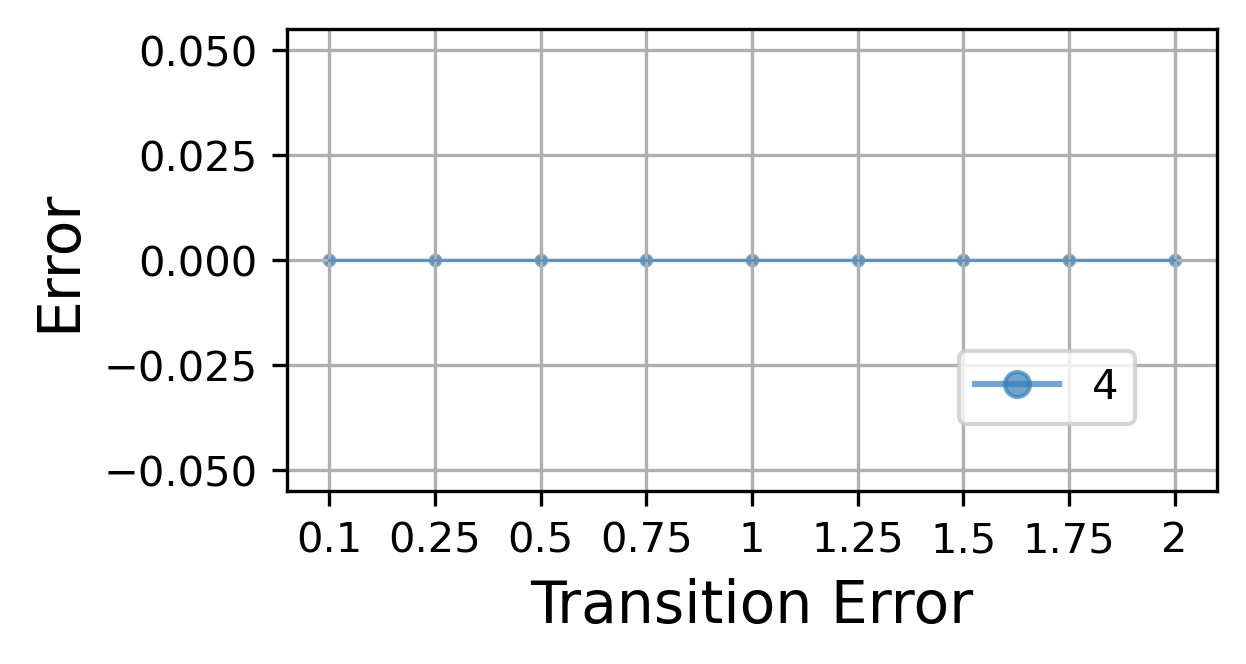

In [255]:
plot_dimensions = (1,1)
x_labels = [["Transition Error"]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(reward_error))),reward_error]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,[[0 for i in range(len(performance_gap[i]))] for i in range(len(performance_gap))],environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/uncertainty_tree.pdf",dpi=300, bbox_inches='tight')

In [243]:
environment_nodes = [15,127]
reward_error = [0.1,0.25,0.5,0.75,1,1.25,1.5,1.75,2]

performance_gap = []

for n in environment_nodes:
    baseline_params = {'environment_string': 'tree', 'environment_nodes': n,'show_baseline': True, 'num_concepts_selected': 4}
    results = get_results_matching_parameters("synthetic","",baseline_params)
    baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
    
    baseline_params['show_baseline'] = False 

    all_values = []

    for error in reward_error:
        baseline_params['reward_error'] = error 
        baseline_params['num_concepts_selected'] = 4
        results = get_results_matching_parameters("synthetic","",baseline_params)
        
        predicted_values = np.mean([r['greedy_selection']['values'][0] for r in results],axis=0)
        diff = np.max(np.abs(predicted_values-baseline_values))
        all_values.append(diff)
    performance_gap.append(all_values)

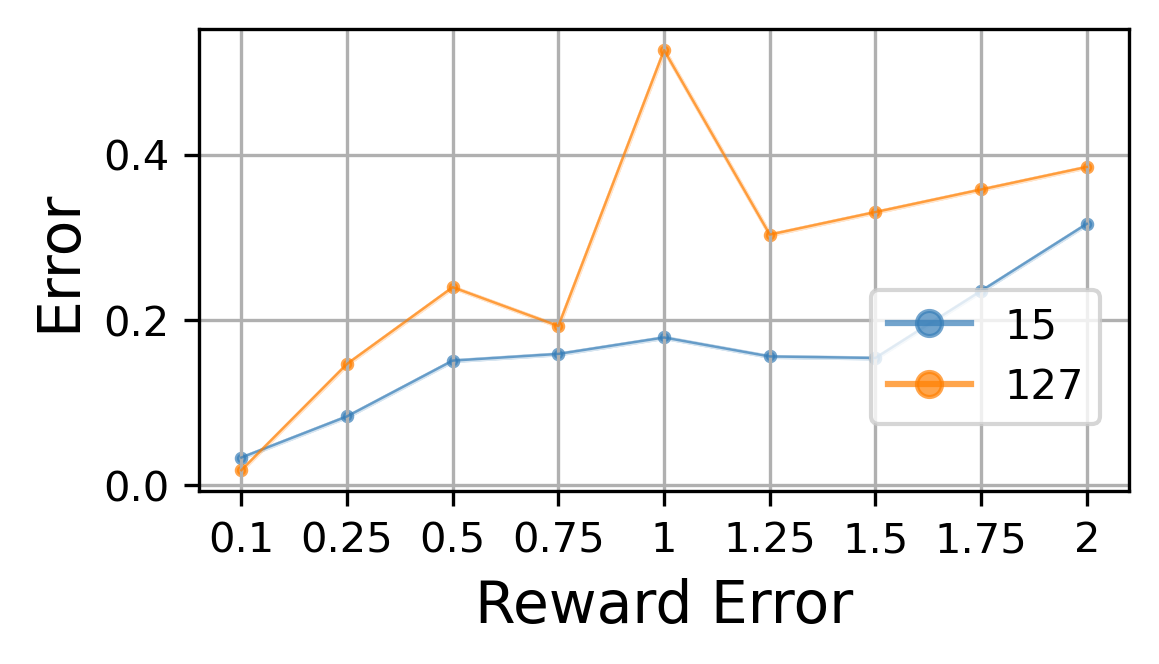

In [242]:
plot_dimensions = (1,1)
x_labels = [["Reward Error"]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(reward_error))),reward_error]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,[[0 for i in range(len(performance_gap[i]))] for i in range(len(performance_gap))],environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/uncertainty_tree.pdf",dpi=300, bbox_inches='tight')

In [256]:
environment_nodes = [15,127]
reward_error = [0.1,0.25,0.5,0.75,1,1.25,1.5,1.75,2]

performance_gap = []

for n in environment_nodes:
    baseline_params = {'environment_string': 'tree', 'environment_nodes': n,'show_baseline': True, 'num_concepts_selected': 4}
    results = get_results_matching_parameters("synthetic","",baseline_params)
    baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
    
    baseline_params['show_baseline'] = False 

    all_values = []

    for error in reward_error:
        baseline_params['transition_error'] = error 
        baseline_params['num_concepts_selected'] = 4
        results = get_results_matching_parameters("synthetic","",baseline_params)
        
        predicted_values = np.mean([r['greedy_selection']['values'][0] for r in results],axis=0)
        diff = np.max(np.abs(predicted_values-baseline_values))
        all_values.append(diff)
    performance_gap.append(all_values)

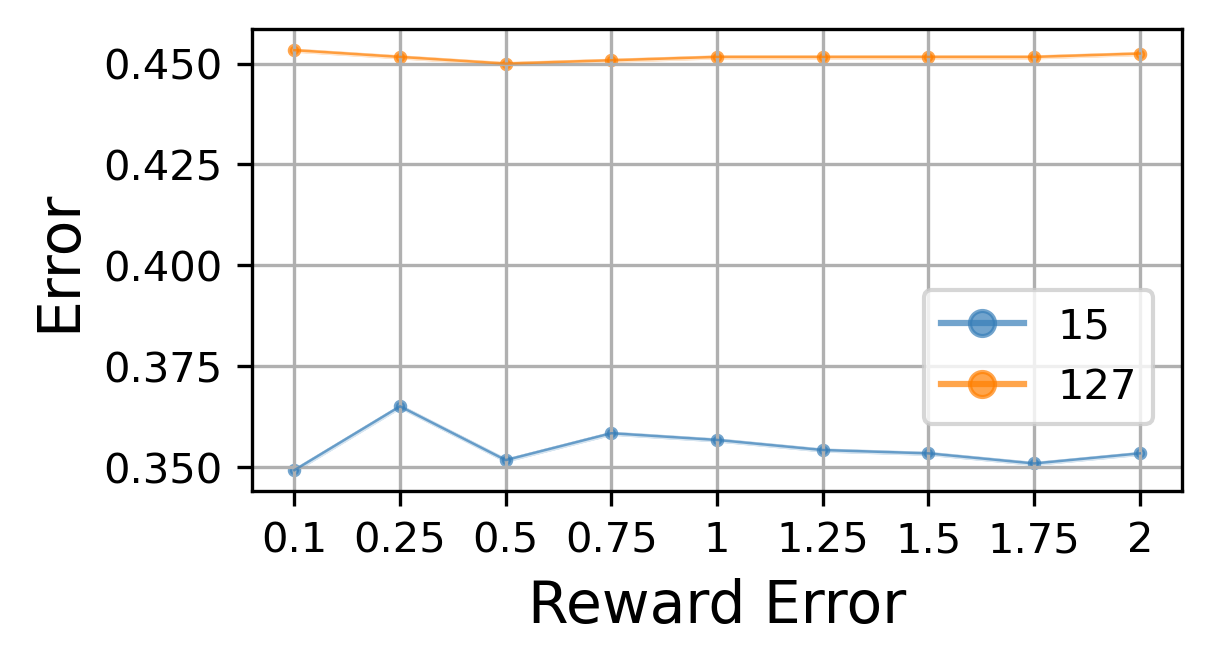

In [258]:
plot_dimensions = (1,1)
x_labels = [["Reward Error"]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(reward_error))),reward_error]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,[[0 for i in range(len(performance_gap[i]))] for i in range(len(performance_gap))],environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/transition_error.pdf",dpi=300, bbox_inches='tight')